In [1]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          16-03-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""

import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV

data = pd.read_csv("data_train.csv", sep = ",")


In [2]:
X = data.drop(columns = ['Churn'])
Y = data["Churn"]


In [ ]:
gridsearch = GridSearchCV(
    estimator = SVC(probability = True), 
    param_grid = [{
        'degree': np.arange(2, 15),
        'C': [0.01, 0.1, 1, 10], 
        'gamma': [0.01, 0.1, 1, 10]}],
    scoring = 'accuracy',
    verbose = 2)

gridsearch.fit(X, Y)
gridsearch.best_estimator_


Fitting 5 folds for each of 208 candidates, totalling 1040 fits
[CV] END .......................C=0.01, degree=2, gamma=0.01; total time=   1.0s
[CV] END .......................C=0.01, degree=2, gamma=0.01; total time=   0.7s
[CV] END .......................C=0.01, degree=2, gamma=0.01; total time=   0.8s
[CV] END .......................C=0.01, degree=2, gamma=0.01; total time=   0.8s
[CV] END .......................C=0.01, degree=2, gamma=0.01; total time=   0.7s
[CV] END ........................C=0.01, degree=2, gamma=0.1; total time=   0.6s
[CV] END ........................C=0.01, degree=2, gamma=0.1; total time=   0.7s
[CV] END ........................C=0.01, degree=2, gamma=0.1; total time=   0.6s
[CV] END ........................C=0.01, degree=2, gamma=0.1; total time=   0.8s
[CV] END ........................C=0.01, degree=2, gamma=0.1; total time=   0.6s
[CV] END ..........................C=0.01, degree=2, gamma=1; total time=   0.7s
[CV] END ..........................C=0.01, de

In [ ]:
test = pd.read_csv("data_test.csv", sep = ",")
X_test = test.drop(columns = ['Churn'])
Y_test = test["Churn"]


In [ ]:
predicted = gridsearch.predict(X_test)


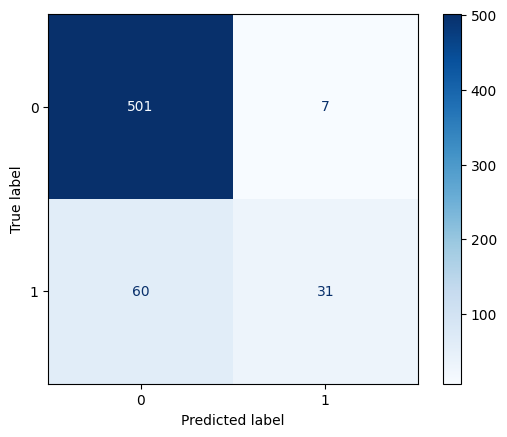

In [ ]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(Y_test, predicted, cmap = 'Blues')
plt.show()


In [ ]:
# Hier worden de accuracy, f1, precision en recall scores berekend en gegeven.
acc = accuracy_score(Y_test, predicted)
rec = recall_score(Y_test, predicted)
pre = precision_score(Y_test, predicted)
fsco = f1_score(Y_test, predicted)
print("SVM accuracy is: {:.2f}".format(acc))
print("SVM recall is: {:.2f}".format(rec))
print("SVM precision is: {:.2f}".format(pre))
print("SVM F1 score is: {:.2f}".format(fsco))


SVM accuracy is: 0.89
SVM recall is: 0.34
SVM precision is: 0.82
SVM F1 score is: 0.48
